# Welcome to the Visual Fusion Project [STARTER]

This project should feel pretty similar to the 3D Object Detection one, except that we'll build our depth map using a LiDAR. Our process is:
1.   **Project the Point Clouds (3D) to the Image(2D)**
2.   **Detect Obstacles in 2D** (Camera)
3.   **Fuse the Results**

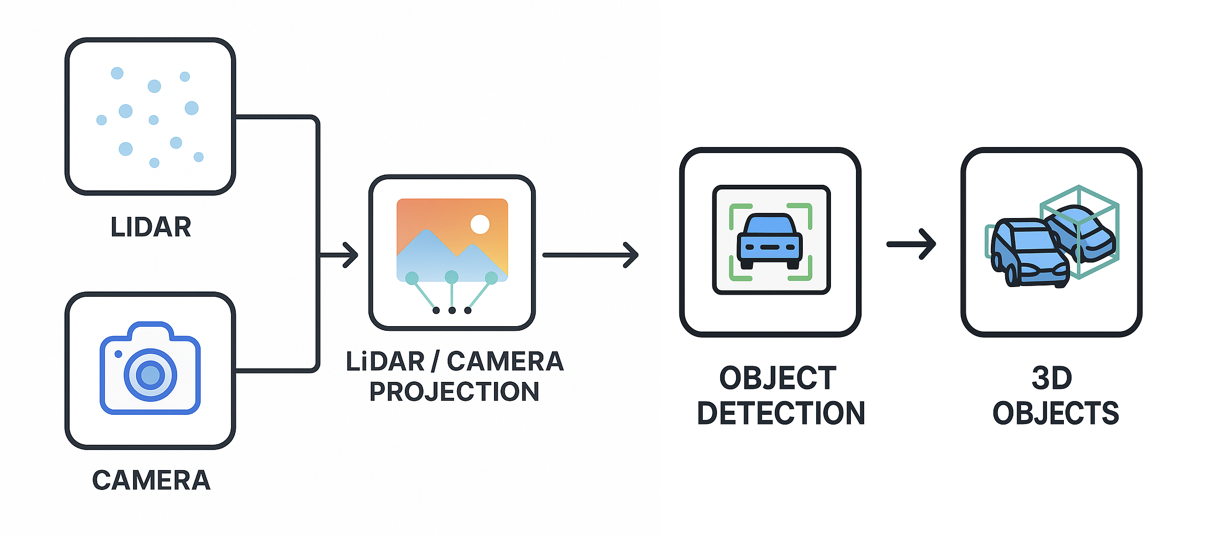

Are you ready? then let's see our TODOs:
## $\color{#DD5566}{\text{TODO: Assignment Progress}}$
* [ ] Run the notebook through the "load data" part
* [ ] Implement the Projection Function TODOs
* [ ] Implement the TODOs for other cells
* [ ] **Squad Assignment:** Choice:Do a side-by-side comparison of 2 techniques:
    * Object Detection versus Segmentation Masks (using [YOLOv11-seg model](https://docs.ultralytics.com/fr/tasks/segment/#models))
    * Visual Fusion versus Depth Maps.

> Publish what you learn in your Hub.
* [ ] The Extra 20% (Optional): Make a video and publish it on LinkedIn

## **Load the Data and Visualize the data**!

In [ ]:
!wget https://visual-fusion.s3.eu-west-3.amazonaws.com/2011_09_26_drive_0009_sync.zip && unzip -qq 2011_09_26_drive_0009_sync.zip

### Import the necessary libraries

In [ ]:
!wget https://github.com/Jeremy26/visual_fusion_course/tree/main/data.zip

In [ ]:
!pip install open3d

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image
import glob
import time
import open3d as o3d
import os

### Load the Files

In [ ]:
!wget https://visual-fusion.s3.eu-west-3.amazonaws.com/data.zip && unzip data.zip

In [ ]:
!mv data ..

In [ ]:
os.chdir("/content/")

In [ ]:
image_files = sorted(glob.glob("data/img/*.png"))
point_files = sorted(glob.glob("data/velodyne/*.pcd"))
label_files = sorted(glob.glob("data/label/*.txt"))
calib_files = sorted(glob.glob("data/calib/*.txt"))

index = 0
pcd_file = point_files[index]
image = cv2.cvtColor(cv2.imread(image_files[index]), cv2.COLOR_BGR2RGB)
cloud = o3d.io.read_point_cloud(pcd_file)
points= np.asarray(cloud.points)

### Visualize the Image

In [ ]:
f, (ax1) = plt.subplots(1, 1, figsize=(20,10))
ax1.imshow(image)
ax1.set_title('Image', fontsize=30)

### Visualize the Point Clouds

In [ ]:
from open3d.visualization.draw_plotly import get_plotly_fig
import plotly.graph_objects as go

distances = np.linalg.norm(points, axis=1)

fig = go.Figure(data=[go.Scatter3d(
    x=points[:, 0],
    y=points[:, 1],
    z=points[:, 2],
    mode='markers',
    marker=dict(
        size=2,
        color=distances,  # use distances for color
        colorscale='Inferno',  # choose a colorscale
        colorbar=dict(title="Distance from Origin", bgcolor="white"),  # add a colorbar title
        opacity=0.8
    )
)])

fig.update_layout(
    scene=dict(
        xaxis=dict(showbackground=False, showline=False, zeroline=False, showgrid=False, showticklabels=False, title=''),
        yaxis=dict(showbackground=False, showline=False, zeroline=False, showgrid=False, showticklabels=False, title=''),
        zaxis=dict(showbackground=False, showline=False, zeroline=False, showgrid=False, showticklabels=False, title=''),
        aspectmode='data',
        camera=dict(
            up=dict(x=-0.2, y=0, z=1),
            center=dict(x=0.2, y=0, z=0.2),
            eye=dict(x=-0.5, y=0, z=0.2))
    ),
    plot_bgcolor='darkgrey',
    paper_bgcolor='darkgrey',
    scene_dragmode='orbit'
)
fig.show()

## **1 - LiDAR/Camera Projection**
That part is possibly the hardest to understand and will require your full attention. We want to project the 3D points into the image.<p>

It means we'll need to: <p>

*   Select the Point that are **visible** in the image 🤔
*   Convert the Points **from the LiDAR frame to the Camera Frame** 🤯
*   Find a way to project **from the Camera Frame to the Image Frame** 😭

<p>
No worries here, we'll figure out everything together.


### 1.1 - Read the Calibration File

The first step is to read the calibration files. For each image, we have an associated calibration file that states:<p>


*   The instrinsic and extrinsic camera calibration parameters
*   The velodyne to camera matrices
*   All the other "sensor A" to "sensor B" matrices
<p>
They are made from this setup:<p>

![link text](http://www.cvlibs.net/datasets/kitti/images/setup_top_view.png)

Not everything matters to us here, only a few things:
*    **Velo-To-Cam is a variable we'll call V2C** -- It gives the rotation and translation matrices from the Velodyne to the Left Grayscale camera.
*    **R0_rect is used in Stereo Vision to make the images co-planar.**
*   **P2 is the matrix obtained after camera calibration**. It contains the intrinsic matrix K and the extrinsic.


In [ ]:
class LiDAR2Camera(object):
    def __init__(self, calib_file):
        calibs = self.read_calib_file(calib_file)
        P = calibs["P2"]
        self.P = np.reshape(P, [3, 4])
        # Rigid transform from Velodyne coord to reference camera coord
        V2C = calibs["Tr_velo_to_cam"]
        self.V2C = np.reshape(V2C, [3, 4])
        # Rotation from reference camera coord to rect camera coord
        R0 = calibs["R0_rect"]
        self.R0 = np.reshape(R0, [3, 3])

    def read_calib_file(self, filepath):
        """ Read in a calibration file and parse into a dictionary.
        Ref: https://github.com/utiasSTARS/pykitti/blob/master/pykitti/utils.py
        """
        data = {}
        with open(filepath, "r") as f:
            for line in f.readlines():
                line = line.rstrip()
                if len(line) == 0:
                    continue
                key, value = line.split(":", 1)
                # The only non-float values in these files are dates, which
                # we don't care about anyway
                try:
                    data[key] = np.array([float(x) for x in value.split()])
                except ValueError:
                    pass
        return data

In [ ]:
lidar2cam = LiDAR2Camera(calib_files[index])
print("P :"+str(lidar2cam.P))
print("-")
print("RO "+str(lidar2cam.R0))
print("-")
print("Velo 2 Cam " +str(lidar2cam.V2C))
print("-")
#print("Cam 2 Velo" + str(lidar2cam.C2V))

### 1.2 - Project the Points in the Image

The main formula we'll use will be as follows:<p>
**Y(2D) = P x R0 x R|t x X (3D)**

However, when looking at the dimensions:

*   P: [3x4]
*   R0: [3x3]
*   R|t = Velo2Cam: [3x4]
*   X: [3x1]

We'll need to convert some points into Homogeneous Coordinates:
* RO must go from 3x3 to 4x3
* x must go from 3x1 to 4x1

Then, to retrieve the cartesian system, we'll divide as explained in the course.

In [ ]:
def cart2hom(self, pts_3d):
    """ Input: nx3 points in Cartesian
        Oupput: nx4 points in Homogeneous by pending 1
    """
    n = pts_3d.shape[0]
    pts_3d_hom = np.hstack((pts_3d, np.ones((n, 1))))
    return pts_3d_hom

LiDAR2Camera.cart2hom = cart2hom

In [ ]:
def project_velo_to_image(self, pts_3d_velo):
    '''
    Input: 3D points in Velodyne Frame [nx3]
    Output: 2D Pixels in Image Frame [nx2]
    '''
    R0_homo = #TODO: Add Row 0s (to be in homogeneous)
    R0_homo_2 = #TODO: Add column 0s (to be in homogeneous)
    p_r0 = #TODO: P * R0
    p_r0_rt =  #TODO: R*RO*R|T
    pts_3d_homo = #TODO: Add columns 0s(to be in homogeneous)
    p_r0_rt_x = #TODO: P*R0*R|T*X (X being pts_3D)
    pts_2d = np.transpose(p_r0_rt_x)

    pts_2d[:, 0] = #TODO: Convert Back to Cartesian
    pts_2d[:, 1] = #TODO: Convert Back to Cartesian
    return #TODO: Return

LiDAR2Camera.project_velo_to_image = project_velo_to_image
print(points[:5,:3])
print("Euclidean Pixels "+str(lidar2cam.project_velo_to_image(points[:5,:3])))


### 1.4 - LiDAR in Image Field Of View

In [ ]:
def get_lidar_in_image_fov(self,pc_velo, xmin, ymin, xmax, ymax, return_more=False, clip_distance=2.0):
    """ Filter lidar points, keep those in image FOV """
    pts_2d = #TODO: Project Velodyne to Camera Image
    fov_inds = (
        (pts_2d[:, 0] < xmax)
        & (pts_2d[:, 0] >= xmin)
        & (pts_2d[:, 1] < ymax)
        & (pts_2d[:, 1] >= ymin)
    )
    fov_inds = fov_inds & (pc_velo[:, 0] > clip_distance) # We don't want things that are closer to the clip distance (2m)
    imgfov_pc_velo = pc_velo[fov_inds, :]
    if return_more:
        return imgfov_pc_velo, pts_2d, fov_inds
    else:
        return imgfov_pc_velo

LiDAR2Camera.get_lidar_in_image_fov = get_lidar_in_image_fov

###1.5 -- Get the LiDAR Points in Pixels

In [ ]:
def show_lidar_on_image(self, pc_velo, img, debug="False"):
    """ Project LiDAR points to image """
    imgfov_pc_velo, pts_2d, fov_inds = #TODO: Call LiDAR FOV
    if (debug==True):
        print("3D PC Velo "+ str(imgfov_pc_velo)) # The 3D point Cloud Coordinates
        print("2D PIXEL: " + str(pts_2d)) # The 2D Pixels
        print("FOV : "+str(fov_inds)) # Whether the Pixel is in the image or not
    self.imgfov_pts_2d = #TODO: Apply FOV Mask

    cmap = plt.cm.get_cmap("hsv", 256)
    cmap = np.array([cmap(i) for i in range(256)])[:, :3] * 255
    self.imgfov_pc_velo = imgfov_pc_velo

    for i in range(self.imgfov_pts_2d.shape[0]):
        depth = #TODO: Select Depth Element
        #print(depth)
        color = cmap[int(510.0 / depth), :]
        cv2.circle(
            img,(int(np.round(self.imgfov_pts_2d[i, 0])), int(np.round(self.imgfov_pts_2d[i, 1]))),2,
            color=tuple(color),
            thickness=-1,
        )

    return img

LiDAR2Camera.show_lidar_on_image = show_lidar_on_image

In [ ]:
#img_3 = lidar2cam.show_lidar_on_image(points[:,:3], image)
img_3 = image.copy()
img_3 = lidar2cam.show_lidar_on_image(points[:,:3], img_3)
plt.figure(figsize=(14,7))
plt.imshow(img_3)
plt.show()

In [ ]:
###BONUS TODO: TRY TO DISPLAY JUST ONE SINGLE POINT!!! DO THE MATHS BEHIND 3D/2D BY HAND - REPORT IT IN YOUR SQUAD HUB

## **2 - Object Detection**

In [ ]:
!pip install ultralytics
!wget https://stereo-vision.s3.eu-west-3.amazonaws.com/yolo11n.pt  #download yolo11n.pt

In [ ]:
from ultralytics import YOLO
model = YOLO("yolo11n.pt")

In [ ]:
def run_obstacle_detection(img_orig):
    start_time=time.time()
    img = img_orig.copy()

    results = model.predict(img)
    result = results[0]
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs

    # Draw Boxes
    rectangle_thickness=1
    text_thickness=1
    boxesfiltered = []

    for box in boxes:
        objecttype = result.names[int(box.cls[0])]
        if objecttype=='person' or objecttype=='car':
            boxesfiltered.append(True)

        else:
            boxesfiltered.append(False)
    exec_time = time.time() - start_time
    #print("time: {:.2f} ms".format(exec_time * 1000))


    newlabels = []
    for label in boxes.cls[boxesfiltered]:
        newlabels.append(result.names[int(label)])
    return img, boxes.xywhn[boxesfiltered], newlabels , boxes.conf[boxesfiltered]

result, pred_bboxes, pred_classes, pred_conf = run_obstacle_detection(image)
plt.imshow(result)

In [ ]:
def draw_predictions(pred_bboxes, pred_classes, pred_conf, img):
    rectangle_thickness = 3
    text_thickness = 3
    h, w, _ = img.shape
    for box,cls,conf in zip(pred_bboxes,pred_classes,pred_conf):
        x1 = int(box[0]*w - box[2]*w*0.5) # center_x - width /2
        y1 = int(box[1]*h-box[3]*h*0.5) # center_y - height /2
        x2 = int(box[0]*w + box[2]*w*0.5) # center_x + width/2
        y2 = int(box[1]*h+box[3]*h*0.5) # center_y + height/2
        objecttype = cls
        if objecttype=='person' or objecttype=='car':
            cv2.rectangle(img, (x1,y1),
                          (x2,y2), (30, 40, 255), rectangle_thickness)
            confidence = conf.numpy().round(2)
            cv2.putText(img, f"{objecttype} - "+str(confidence),
                        (x1, y1 - 3),
                        cv2.FONT_HERSHEY_PLAIN, 1, (30, 40, 255), text_thickness)

    return img

result = draw_predictions(pred_bboxes,pred_classes,pred_conf,img_3)
plt.imshow(result)
plt.show()

#### **Hero: Use Segmentation**
YOLOv11 is capable of running segmentation just as well as object detection. What about using it? On this page, you can download some models: https://docs.ultralytics.com/fr/tasks/segment/#models
I recommend you try this in your squad assignment just here.

## **3 - Fusion**

**Now, let's see a few ways to filter outliers.** <p>
Outliers are the points that belong to the bounding box, but not to the object.<p>
Here's an example of outliers:<p>
![outlier image](https://i.ibb.co/Fg0KV3k/Screenshot-2021-05-31-at-22-31-29.png)

In this image, the points belong to the truck, but are also counted as part of the car.

The first technique we can use for that is a shrink factor.
Instead of considering the whole bounding box, we're considering only a part of it. **A common choice is 10-15% shrinking.**
![image_shrinks](https://i.ibb.co/Zcgzz6F/Screenshot-2021-05-31-at-22-45-36.png)

In [ ]:
print(pred_bboxes)

In [ ]:
def rectContains(rect,pt, w, h, shrink_factor = 0):
    x1 = int(rect[0]*w - rect[2]*w*0.5*(1-shrink_factor)) # center_x - width /2 * shrink_factor
    y1 = int(rect[1]*h-rect[3]*h*0.5*(1-shrink_factor)) # center_y - height /2 * shrink_factor
    x2 = int(rect[0]*w + rect[2]*w*0.5*(1-shrink_factor)) # center_x + width/2 * shrink_factor
    y2 = int(rect[1]*h+rect[3]*h*0.5*(1-shrink_factor)) # center_y + height/2 * shrink_factor

    return x1 < pt[0]<x2 and y1 <pt[1]<y2

**The second way will be through Outlier removal techniques. <p>**
We can cite a few: 3 Sigma, RANSAC, and others...

In [ ]:
import statistics
import random

def filter_outliers(distances):
    inliers = []
    mu  = statistics.mean(distances)
    std = statistics.stdev(distances)
    for x in distances:
        if abs(x-mu) < std:
            # This is an INLIER
            inliers.append(x)
    return inliers

def get_best_distance(distances, technique="closest"):
    if technique == "closest":
        return min(distances)
    elif technique =="average":
        return statistics.mean(distances)
    elif technique == "random":
        return random.choice(distances)
    else:
        return statistics.median(sorted(distances))


In [ ]:
def lidar_camera_fusion(self, pred_bboxes, image):
    img_bis = image.copy()

    cmap = plt.cm.get_cmap("hsv", 256)
    cmap = np.array([cmap(i) for i in range(256)])[:, :3] * 255
    distances = []
    for box in pred_bboxes:
        distances = []
        for i in range(self.imgfov_pts_2d.shape[0]):
            depth = #TODO: Grab Depth
            if (rectContains(box, self.imgfov_pts_2d[i], image.shape[1], image.shape[0], shrink_factor=0.2)==True):
                #TODO: What should happen here?

                color = cmap[int(510.0 / depth), :]
                cv2.circle(img_bis,(int(np.round(self.imgfov_pts_2d[i, 0])), int(np.round(self.imgfov_pts_2d[i, 1]))),2,color=tuple(color),thickness=-1,)
        h, w, _ = img_bis.shape
        if (len(distances)>2):
            distances = #TODO: Filter outliers
            best_distance = #TODO: Get best distance
            cv2.putText(img_bis, '{0:.2f} m'.format(best_distance), (int(box[0]*w),int(box[1]*h)), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 0, 0), 3, cv2.LINE_AA)
        distances_to_keep = []

    return img_bis, distances

LiDAR2Camera.lidar_camera_fusion = lidar_camera_fusion

In [ ]:
final_result, _ = lidar2cam.lidar_camera_fusion(pred_bboxes, result)

fig_keeping = plt.figure(figsize=(14, 7))
ax_keeping = fig_keeping.subplots()
ax_keeping.imshow(final_result)
plt.show()

### Build a Pipeline

In [ ]:
def pipeline (self, image, point_cloud):
    "For a pair of 2 Calibrated Images"
    img = image.copy()
    # Show LidAR on Image
    lidar_img = self.show_lidar_on_image(point_cloud[:,:3], image)
    # Run obstacle detection in 2D
    result, pred_bboxes, pred_classes, pred_conf = run_obstacle_detection(img)
    # Fuse Point Clouds & Bounding Boxes
    img_final, _ = self.lidar_camera_fusion(pred_bboxes, result)
    return img_final

LiDAR2Camera.pipeline = pipeline

In [ ]:
image_files = sorted(glob.glob("data/img/*.png"))
point_files = sorted(glob.glob("data/velodyne/*.pcd"))
label_files = sorted(glob.glob("data/label/*.txt"))
calib_files = sorted(glob.glob("data/calib/*.txt"))

lidar2cam = LiDAR2Camera(calib_files[index])
cloud = o3d.io.read_point_cloud(pcd_file)
points= np.asarray(cloud.points)

index = 0
image = cv2.cvtColor(cv2.imread(image_files[index]), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,7))
final_result = lidar2cam.pipeline(image, points)
plt.imshow(final_result)
plt.show()

## Comparing with the Ground Truth


In [ ]:
image_gt = image.copy()

with open(label_files[index], 'r') as f:
    fin = f.readlines()
    for line in fin:
        if line.split(" ")[0] != "DontCare":
            #print(line)
            x1_value = int(float(line.split(" ")[4]))
            y1_value = int(float(line.split(" ")[5]))
            x2_value = int(float(line.split(" ")[6]))
            y2_value = int(float(line.split(" ")[7]))
            dist = float(line.split(" ")[13])
            cv2.rectangle(image_gt, (x1_value, y1_value), (x2_value, y2_value), (0,205,0), 10)
            cv2.putText(image_gt, str(dist), (int((x1_value+x2_value)/2),int((y1_value+y2_value)/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2, cv2.LINE_AA)

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(30,20))
ax1.imshow(image_gt)
ax1.set_title('Ground Truth', fontsize=30)
ax2.imshow(final_result) # or flag
ax2.set_title('Prediction', fontsize=30)

## Shooting a Portfolio Video

For more videos:
Here is the list, download and add to your Drive Folder (it's only a few Mb):

*   [INITIAL VIDEO](https://drive.google.com/drive/folders/1pjYqlStUbtcI46mKhakv0aAyZWxgNnmT?usp=sharing)
*   [URBAN AREA](https://drive.google.com/drive/folders/1Fg5lW9eC61Fyk-y62EDHmIr4ezBHEfQk?usp=sharing)
*   [RURAL AREA](https://drive.google.com/drive/folders/1s4n_ukH7Ujp1V6u8GaYUZrLhNNDzZlmO?usp=sharing)
*   [HIGHWAY](https://drive.google.com/drive/folders/1MrRHWnuO2uZnmXCC38t3vq2d1lD4x2HJ?usp=sharing)


If you'd like to work on more videos, go here and pick from the LONG list!
The Point Clouds will be in BINARY mode, use this script to convert these to PCD.

In [ ]:
video_images = sorted(glob.glob("data/video 4/images/*.png"))
video_points = sorted(glob.glob("data/video 4/points/*.pcd"))

# Build a LiDAR2Cam object
lidar2cam_video = LiDAR2Camera(calib_files[0])

result_video = []

for idx, img in enumerate(video_images):
    image = cv2.cvtColor(cv2.imread(img), cv2.COLOR_BGR2RGB)
    point_cloud = np.asarray(o3d.io.read_point_cloud(video_points[idx]).points)
    result_video.append(lidar2cam_video.pipeline(image, point_cloud))

#out = cv2.VideoWriter('output/out.avi',cv2.VideoWriter_fourcc(*'DIVX'), 15, (image.shape[1],image.shape[0]))
out = cv2.VideoWriter('output/out_4.mp4',cv2.VideoWriter_fourcc(*'MP4V'), 15, (image.shape[1],image.shape[0]))

for i in range(len(result_video)):
    out.write(cv2.cvtColor(result_video[i], cv2.COLOR_BGR2RGB))
    #out.write(result_video[i])
out.release()

### Optional - If your LiDAR file is in binary extension '.bin', use this piece of code to turn it into a '.pcd' and save it

In [ ]:
## BIN TO PCD
import numpy as np
import struct
size_float = 4
list_pcd = []

file_to_open = point_files[index]
file_to_save = str(point_files[index])[:-3]+"pcd"
with open (file_to_open, "rb") as f:
    byte = f.read(size_float*4)
    while byte:
        x,y,z,intensity = struct.unpack("ffff", byte)
        list_pcd.append([x, y, z])
        byte = f.read(size_float*4)
np_pcd = np.asarray(list_pcd)
pcd = o3d.geometry.PointCloud()
v3d = o3d.utility.Vector3dVector
pcd.points = v3d(np_pcd)

o3d.io.write_point_cloud(file_to_save, pcd)
